# Process ATUS data

Outcomes:
- Filter and process respondent metadata and export into a csv
- Generate wide-form sequences from time diaries and export into a csv
- Perform clustering on the ATUS sequences
- Export cluster and demographic stratum codes into a csv

In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from weighted_levenshtein import lev
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, optimal_leaf_ordering
from scipy.spatial.distance import squareform

%config InlineBackend.figure_format = 'retina'

In [2]:
from plotting import cluster_tempogram_weighted
from get_atus import get_resp, get_who_df, get_diaries, map_tewhere
from seq_atus import stage_diaries, stage_sequence, sequence

## Construct ATUS sequences

In [3]:
dy = 24 # data year
ty = 19 # to year
resp_dir = f'data/atus/atusresp-03{dy}/atusresp_03{dy}.dat'
cps_dir = f'data/atus/atuscps-03{dy}/atuscps_03{dy}.dat'
who_dir = f'data/atus/atuswho-03{dy}/atuswho_03{dy}.dat'
act_dir = f'data/atus/atusact-03{dy}/atusact_03{dy}.dat'
years = [y for y in range(2004, 2000+ty+1) if y != 2020]
cbsa_filter_list = [38060] # cbsa codes (cbsas should match with the mobility sample)
age_min = 18

In [4]:
# load and process respondent data, who data, and time diaries

resp = get_resp(resp_dir, cps_dir, years, cbsa_filter_list, age_min)
who = get_who_df(who_dir, resp)
diaries = get_diaries(act_dir, resp, who)

/Users/unchitta/Research/lopez_research/mobcalibrate/examples/get_atus.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['GTCO'] = df[['GESTFIPS','GTCO']].apply(lambda x: x[0]+x[1] if x[1]!="000" else x[1], axis=1)
/Users/unchitta/Research/lopez_research/mobcalibrate/examples/get_atus.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  income_level = x[1] if x[0] > 2009 else x[2] # if year > 2019 use HEFAMINC o/w use HUFAMINC
/Users/unchitta/Research/lopez_research/mobcalibrate/examples/get_atus.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer key

In [5]:
resp

,TUCASEID,TUYEAR,TUMONTH,TUDIARYDAY,TUDIARYDATE,GTCBSA,GTCO,TUFINLWGT,FEMALE,AGE,EMPLOYED,EMPLOY_TYPE,INCOME_GROUP,COLLEGE,MAR,CHILDREN,MAR_CHILD,RACE
0,20040707040543,2004,7,weekday,20040728,38060,4013,20255.140632,0,59.0,1,1,14.0,1,1,0,2,1
1,20040707040558,2004,7,weekend,20040731,38060,4013,8612.078956,0,44.0,1,1,14.0,1,1,0,2,1
2,20040807040006,2004,8,weekend,20040808,38060,4013,13895.869568,0,55.0,0,3,11.0,0,0,0,1,1
3,20040807040542,2004,8,weekend,20040808,38060,4013,39687.590746,0,21.0,0,3,10.0,0,0,1,1,3
4,20040807040553,2004,8,weekend,20040821,38060,4013,2537.938345,0,47.0,1,1,8.0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028,20191211192139,2019,12,weekend,20191221,38060,4013,12177.142158,0,44.0,1,1,7.0,0,0,0,1,1
2029,20191211192394,2019,12,weekday,20191211,38060,4013,69774.777569,0,21.0,1,1,13.0,0,0,0,1,4
2030,20191212190533,2019,12,weekend,20191222,38060,4013,14709.465924,1,76.0,1,2,13.0,0,1,0,2,1
2031,20191212191319,2019,12,weekend,20191228,38060,4013,28148.385455,0,25.0,1,1,11.0,0,1,0,2,1


In [6]:
### Map TEWHERE code into alphabet
### Users have a choice here of what categories to collapse
### (Categories can be collapsed further when building sequence distances)

tewhere_map = {
    1: 1, # home
    2: 2, # work
    3: 3, # someone else's home -> other place
    4: 4, # restaurants/bars
    5: 3, # place of worship -> other place
    6: 5, # grocery store
    7: 5, # other store/mall
    8: 6, # school
    9: 7, # outdoors away from home
    31: 3, # gym/health club -> other place
    10: 3, # library -> other place
    11: 3, # other place -> other place
    30: 3, # bank -> other place
    32: 3, # post office -> other place
    89: 3, # unspecified -> other place
    # all other: 3 (modes of transportation/travel -> other place)
} # 7 total letters


tewhere_map_labels = {
    1: "home",
    2: "work",
    3: "other place",
    4: "restaurants/bars",
    5: "stores/mall",
    6: "school",
    7: "outdoors",
    8: "transport"
}


tewhere_map = defaultdict(lambda: 8, tewhere_map)
diaries = map_tewhere(tewhere_map, diaries)

/Users/unchitta/Research/lopez_research/mobcalibrate/examples/get_atus.py:208: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  diaries['TEWHERE'] = diaries['TEWHERE'].replace(to_replace=-1, method='bfill')


In [7]:
### construct wide-form sequences from diaries

# set cell width, e.g. 30 minutes
T = 30 

# stage diaries for sequencing
staged_diaries = stage_diaries(diaries)

# stage sequences using seq_col as a basis for building sequences
staged_sequence = stage_sequence(staged_diaries, seq_col='WHERE')

# generate sequences
seq_data = sequence(staged_sequence, T)

seq_data

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
TUCASEID,,,,,,,,,,,,,,,,,,,,,
20040707040543,1,1,1,1,1,1,1,8,2,2,...,1,1,1,1,1,1,1,1,1,1
20040707040558,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040006,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040542,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040553,1,1,1,1,1,1,1,1,1,8,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20191211192139,1,1,1,1,1,1,1,8,5,5,...,1,1,1,1,1,1,1,1,1,1
20191211192394,1,1,1,1,1,8,8,2,2,2,...,1,1,1,1,1,1,1,1,1,1
20191212190533,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [62]:
# save sequences and respondent data
resp.to_csv('data/processed/atus_resp.csv')
seq_data.to_csv('data/processed/atus_seq.csv')

## Cluster ATUS sequences

In [ ]:
## TODO: refactor notebook and move functions into distances.py and clustering.py

In [8]:
### convert sequences into a sequence of alphabet to satisfy weighted_levenshtein package requirement

tewhere_map_labels = {
    1: "home",
    2: "work",
    3: "other place",
    4: "restaurants/bars",
    5: "stores/mall",
    6: "school",
    7: "outdoors",
    8: "transport"
}

map_to_alpha = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'C',#'D',
    5: 'C',#'E',
    6: 'C',#'F',
    7: 'C',#'G',
    8: 'C' #transport -> other
}
seq = seq_data.replace({8: 3})
seq_alpha = seq.applymap(lambda x: map_to_alpha[x]).astype(str).agg(''.join, axis=1).values

/var/folders/93/hgn3_dbn5ld2wxv1dryhbyvw0000gn/T/ipykernel_483/3959388301.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  seq_alpha = seq.applymap(lambda x: map_to_alpha[x]).astype(str).agg(''.join, axis=1).values


In [9]:
seq

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
TUCASEID,,,,,,,,,,,,,,,,,,,,,
20040707040543,1,1,1,1,1,1,1,3,2,2,...,1,1,1,1,1,1,1,1,1,1
20040707040558,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040006,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040542,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
20040807040553,1,1,1,1,1,1,1,1,1,3,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20191211192139,1,1,1,1,1,1,1,3,5,5,...,1,1,1,1,1,1,1,1,1,1
20191211192394,1,1,1,1,1,3,3,2,2,2,...,1,1,1,1,1,1,1,1,1,1
20191212190533,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [10]:
seq_alpha

array(['AAAAAAACBBBBBBBBBCBBBBBBBBAAAAAAAAAAAAAAAAAAAAAA',
       'AAAAAAAAAAAAAAACCCCCCCCCAAACAAAAAAAAAAAAAAAAAAAA',
       'AAAAAAAAAAAAACCCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA', ...,
       'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACAAAAAAAAAAAAAA',
       'AAAAAACCAAAAAAACCCCCCCCCCCCCCCCCAAAAAAAAAAAAAAAA',
       'AAAAAAAAAAAAAAAAAAAAAAACCCAAAAAAAAAAAAAAAAAAAAAA'], dtype=object)

In [11]:
# make distance matrices compliant to weighted_levenshtein requirements
def make_costs(dist_type):
    if dist_type == 'lev1':
        indel_factor = 1
        sub_factor = 1
    elif dist_type == 'lev2':
        indel_factor = 1
        sub_factor = 999999
    elif dist_type == 'hamming':
        indel_factor = 999999
        sub_factor = 1
    
    indel_costs = np.ones(128, dtype=np.float64) * indel_factor
    substitute_costs = np.ones((128, 128), dtype=np.float64) * sub_factor

    return indel_costs, substitute_costs

def hierarchical_clustering(D, kmax=8, dendogram=False):
    d = squareform(D, checks=False)
    Z = linkage(d, method='ward')
    Z = optimal_leaf_ordering(Z, d)

    #coph_r, _ = cophenet(Z, d)

    labels_k = fcluster(Z, t=kmax, criterion='maxclust')

    if dendogram:
        plt.figure(figsize=(8, 4))
        dendrogram(Z, no_labels=True, count_sort=True)
        plt.tight_layout()
        plt.show()

    return d, Z, labels_k

# aesthetics tempogram wrapper
def cluster_tempogram_weighted_wrapper(data, cluster_labels, suptitle, legend_labels=None):

    # Aesthetics options for tempograms
    colors = plt.cm.nipy_spectral_r(np.linspace(0, 1, 12))
    colors = ['lightgrey','orange','red','blue','turquoise','purple','green','black']
    xticks = [t for t in range(0,48,2)]
    xlabs = [t for t in range(4,25)] + [t for t in range(1,4)]
    if legend_labels is None:
        legend_labels = tewhere_map_labels

    cluster_tempogram_weighted(
        data, 
        cluster_labels,
        1, 
        colors = colors,
        xticks = xticks,
        xlabs = xlabs,
        legend_labels = legend_labels,
        suptitle = suptitle,
        )

In [ ]:
### WEIGHTED KMEDOIDS

def _weighted_inertia(D, medoids, w):
    """Weighted sum of distances to nearest medoid."""
    # D: (n,n) distance matrix; medoids: list/array of medoid indices; w: (n,)
    dmin = np.min(D[:, medoids], axis=1)
    return float((w * dmin).sum())

def _init_kmedoids_plusplus(D, k, w, rng):
    """
    k-medoids++ style initialization using weighted probabilities.
    Start with a random point ~ weight; then sample others ~ w * (dist-to-nearest)^2.
    """
    n = D.shape[0]
    medoids = []
    # first medoid: weighted random
    probs = w / w.sum()
    m0 = rng.choice(n, p=probs)
    medoids.append(m0)
    # subsequent medoids
    for _ in range(1, k):
        dmin = np.min(D[:, medoids], axis=1)
        # probability proportional to weight * distance^2
        p = w * (dmin ** 2)
        p_sum = p.sum()
        if p_sum == 0:
            # all points coincide w.r.t. chosen medoids; pick random by weight
            m = rng.choice(n, p=w/w.sum())
        else:
            p = p / p_sum
            m = rng.choice(n, p=p)
        medoids.append(int(m))
    return np.array(sorted(set(medoids)))  # guard against duplicates

def weighted_kmedoids(
    D, k, w=None, max_iter=200, tol=1e-6, init="kmedoids++", random_state=0, verbose=False
):
    """
    Weighted K-medoids (PAM) on a precomputed distance matrix.

    Parameters
    ----------
    D : (n,n) ndarray
        Symmetric distance matrix, zeros on diagonal.
    k : int
        Number of clusters / medoids.
    w : (n,) ndarray or None
        Nonnegative weights per point (survey weights). Defaults to ones.
    init : {'random','kmedoids++', array-like}
        Initialization: random, kmedoids++ (weighted), or explicit medoid indices.
    """
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    if w is None:
        w = np.ones(n, dtype=float)
    else:
        w = np.asarray(w, dtype=float)
        if np.any(w < 0):
            raise ValueError("Weights must be nonnegative.")
        if w.sum() == 0:
            w = np.ones(n, dtype=float)

    # --- initialize medoids
    if isinstance(init, (list, np.ndarray)):
        medoids = np.array(init, dtype=int)
    elif init == "random":
        probs = w / w.sum()
        medoids = rng.choice(n, size=k, replace=False, p=probs)
    elif init == "kmedoids++":
        medoids = _init_kmedoids_plusplus(D, k, w, rng)
        # if duplicates happened, fill up randomly
        while len(medoids) < k:
            cand = rng.choice(n, p=w/w.sum())
            if cand not in medoids:
                medoids = np.append(medoids, cand)
    else:
        raise ValueError("Unknown init")

    # ensure size k
    if len(medoids) != k:
        raise ValueError("Initialization did not produce k distinct medoids.")

    # Precompute assignment structures
    d_to_m = np.min(D[:, medoids], axis=1)
    nearest_m = medoids[np.argmin(D[:, medoids], axis=1)]
    inertia = float((w * d_to_m).sum())

    if verbose:
        print(f"init inertia={inertia:.6f}")

    # --- PAM SWAP loop
    improved = True
    it = 0
    while improved and it < max_iter:
        improved = False
        it += 1
        for mi_idx, mi in enumerate(list(medoids)):
            # Try swapping out medoid mi with every non-medoid h
            non_m = [h for h in range(n) if h not in medoids]
            best_delta = 0.0
            best_h = None

            for h in non_m:
                # Compute change in weighted inertia if we swap mi -> h
                # For each point x, its new distance is min( old-best (unless mi was its best), D[x,h], other medoids )
                # Efficient computation:
                # current best distance d1; current second-best distance d2 (w.r.t. current medoids)
                d_all = D[:, medoids]
                # obtain second-best distances by masking the column of mi
                d1 = d_to_m
                # column index of mi in current medoids:
                col_mi = mi_idx
                # second-best = min over all medoids except mi
                if k > 1:
                    mask = np.ones(k, dtype=bool)
                    mask[col_mi] = False
                    d2 = np.min(d_all[:, mask], axis=1)
                else:
                    d2 = np.full(n, np.inf)

                # candidate distance via new medoid h
                dh = D[:, h]
                # If mi was not the nearest, new best = min(d1, dh)
                # If mi was the nearest, new best = min(d2, dh)
                is_near_mi = (nearest_m == mi)
                new_best = np.where(is_near_mi, np.minimum(d2, dh), np.minimum(d1, dh))

                delta = (w * (new_best - d1)).sum()   # change in objective
                if delta < best_delta:
                    best_delta = delta
                    best_h = h

            # Apply best swap for this medoid if it improves
            if best_h is not None and best_delta < -tol:
                # perform swap
                medoids[mi_idx] = best_h
                # update nearest distances and assignments
                d_to_m = np.min(D[:, medoids], axis=1)
                nearest_m = medoids[np.argmin(D[:, medoids], axis=1)]
                inertia += best_delta
                improved = True
                if verbose:
                    print(f"iter {it}: swap {mi} -> {best_h}, inertia={inertia:.6f}")

        if not improved and verbose:
            print(f"no improving swap at iter {it}, inertia={inertia:.6f}")

    # Final labels
    labels = np.argmin(D[:, medoids], axis=1)
    return medoids, labels, inertia

def fit_weighted_kmedoids_with_restarts(D, wA, K, n_restarts=10, random_state=0, **kwargs):
    """
    Run your weighted_kmedoids several times and keep the best (lowest inertia).
    kwargs are passed to weighted_kmedoids (e.g., max_iter, tol, init, verbose).
    """
    rng = np.random.default_rng(random_state)
    best = None
    for r in range(n_restarts):
        seed = int(rng.integers(0, 2**31-1))
        medoids, labels, inertia= weighted_kmedoids(
            D, K, w=wA, random_state=seed, **kwargs
        )
        if (best is None) or (inertia < best["inertia"]):
            best = {"medoids": medoids, "labels": labels, "inertia": inertia, "seed": seed}
    return best

In [13]:
######################
# METRICS
# Given a sequence, return all the metrics
######################
def sequence_metrics(
    seq,
    home_label="1", # Home
    work_label="2", # Work
    all_labels=None
):
    
    """
    Compute behavioural sequence metrics for a single daily activity sequence.

    Args:
        seq (list): A list of activity labels (e.g. ["Home","Work","Work","Commute"...])
        home_label (str): Label used for "Home" activity
        work_label (str): Label used for "Work" activity
        all_labels (list): Optional list of all possible activity labels in the alphabet

    Returns:
        dict: A dictionary with metrics
    """

    from collections import Counter
    
    # Length
    n = len(seq)

    # Unique activities
    distinct = set(seq)
    num_activities = len(distinct)

    # Activity durations (simple count)
    counts = Counter(seq)
    durations = {act: counts[act]/48 if act in counts else 0 for act in all_labels}

    # Turnover rate = # of transitions / (length - 1)
    transitions = sum(
        1 for i in range(1, n) if seq[i] != seq[i - 1]
    )
    turnover_rate = transitions / (n - 1) if n > 1 else 0


    ###############################
    # Helper: find runs/spells
    def compute_runs(sequence):
        run_lengths = []
        current_state = sequence[0]
        current_length = 1
        for i in range(1, len(sequence)):
            if sequence[i] == current_state:
                current_length += 1
            else:
                run_lengths.append((current_state, current_length))
                current_state = sequence[i]
                current_length = 1
        run_lengths.append((current_state, current_length))
        return run_lengths

    ###################################
    # Helper: reciprocity from spells
    def compute_reciprocity(runs):

        # <<< MOD: handle single-activity sequences explicitly
        if len(runs) == 1:
            state = runs[0][0]
            edge_counts = Counter({(state, state): 1})
            return 0.0, dict(edge_counts)

        transitions = [(runs[i][0], runs[i+1][0]) for i in range(len(runs) - 1)]
        edge_set = set(transitions)

        # Count edges
        edge_counts = Counter(transitions)

        # ----- Weighted reciprocity -----
        weighted_mutual = sum(
            min(w, edge_counts.get((j, i), 0))
            for (i, j), w in edge_counts.items()
            if i != j
        )

        total_weight = sum(
            w for (i, j), w in edge_counts.items()
            if i != j
        )

        weighted_reciprocity = (
            weighted_mutual / total_weight
            if total_weight > 0 else 0.0
        )

        return weighted_reciprocity, dict(edge_counts)

    runs = compute_runs(seq)
    reciprocity, edges = compute_reciprocity(runs)



    '''
    # Average run durations by activity
    run_lengths_by_activity = {}
    for state, length in runs:
        run_lengths_by_activity.setdefault(state, []).append(length)

    avg_run_duration = {
        act: np.mean(run_lengths_by_activity.get(act, [0]))
        for act in run_lengths_by_activity
    }

    avg_home_run = np.mean([l for s, l in runs if s == home_label]) if any(s == home_label for s, l in runs) else 0
    avg_work_run = np.mean([l for s, l in runs if s == work_label]) if any(s == work_label for s, l in runs) else 0


    # Time at Home and Work
    time_home = counts.get(home_label, 0) / 48
    time_work = counts.get(work_label, 0) / 48


    # Sequence Complexity Index
    if all_labels is not None and len(all_labels) > 0:
        # theoretical max entropy = loge(# of states in alphabet)
        hmax = np.log(len(all_labels))
    else:
        hmax = np.log(num_activities) if num_activities > 0 else 1
    seq_complexity = (
        np.sqrt((transitions / n) * (entr / hmax))
        if n > 0 and hmax > 0
        else 0
    )
    '''



    res = {
        "num_activities": num_activities,
        "turnover_rate": turnover_rate,
        "reciprocity": reciprocity
    }

    # Durations as Time Use
    for k, v in durations.items():
        res[k] = v

    # Edges
    for k, v in edges.items():
        res[f"edge_{k}"] = v

    return res


#### Make alignment cost matrix

In [14]:
metrics = []
for s in seq_alpha:
    m = sequence_metrics(s, "A", "B", ["A","B","C"])
    metrics.append(m)
seq_metrics = pd.DataFrame(metrics).fillna(0)
seq_metrics

,num_activities,turnover_rate,reciprocity,A,B,C,"edge_('A', 'C')","edge_('C', 'B')","edge_('B', 'C')","edge_('B', 'A')","edge_('C', 'A')","edge_('A', 'A')","edge_('A', 'B')"
0,3,0.106383,0.4,0.604167,0.354167,0.041667,1.0,2.0,1.0,1.0,0.0,0.0,0.0
1,2,0.085106,1.0,0.791667,0.000000,0.208333,2.0,0.0,0.0,0.0,2.0,0.0,0.0
2,2,0.042553,1.0,0.937500,0.000000,0.062500,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,0.042553,1.0,0.833333,0.000000,0.166667,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,0.127660,1.0,0.750000,0.000000,0.250000,3.0,0.0,0.0,0.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028,2,0.127660,1.0,0.437500,0.000000,0.562500,3.0,0.0,0.0,0.0,3.0,0.0,0.0
2029,3,0.085106,1.0,0.479167,0.437500,0.083333,1.0,1.0,1.0,0.0,1.0,0.0,0.0
2030,2,0.042553,1.0,0.979167,0.000000,0.020833,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2031,2,0.085106,1.0,0.604167,0.000000,0.395833,2.0,0.0,0.0,0.0,2.0,0.0,0.0


In [15]:
from sklearn.metrics.pairwise import pairwise_distances

cosine_D = pairwise_distances(seq_metrics, seq_metrics, metric='cosine')

#### Example weighted K-medoids clustering with 4 clusters

Cluster sizes: [708 490 265 570]


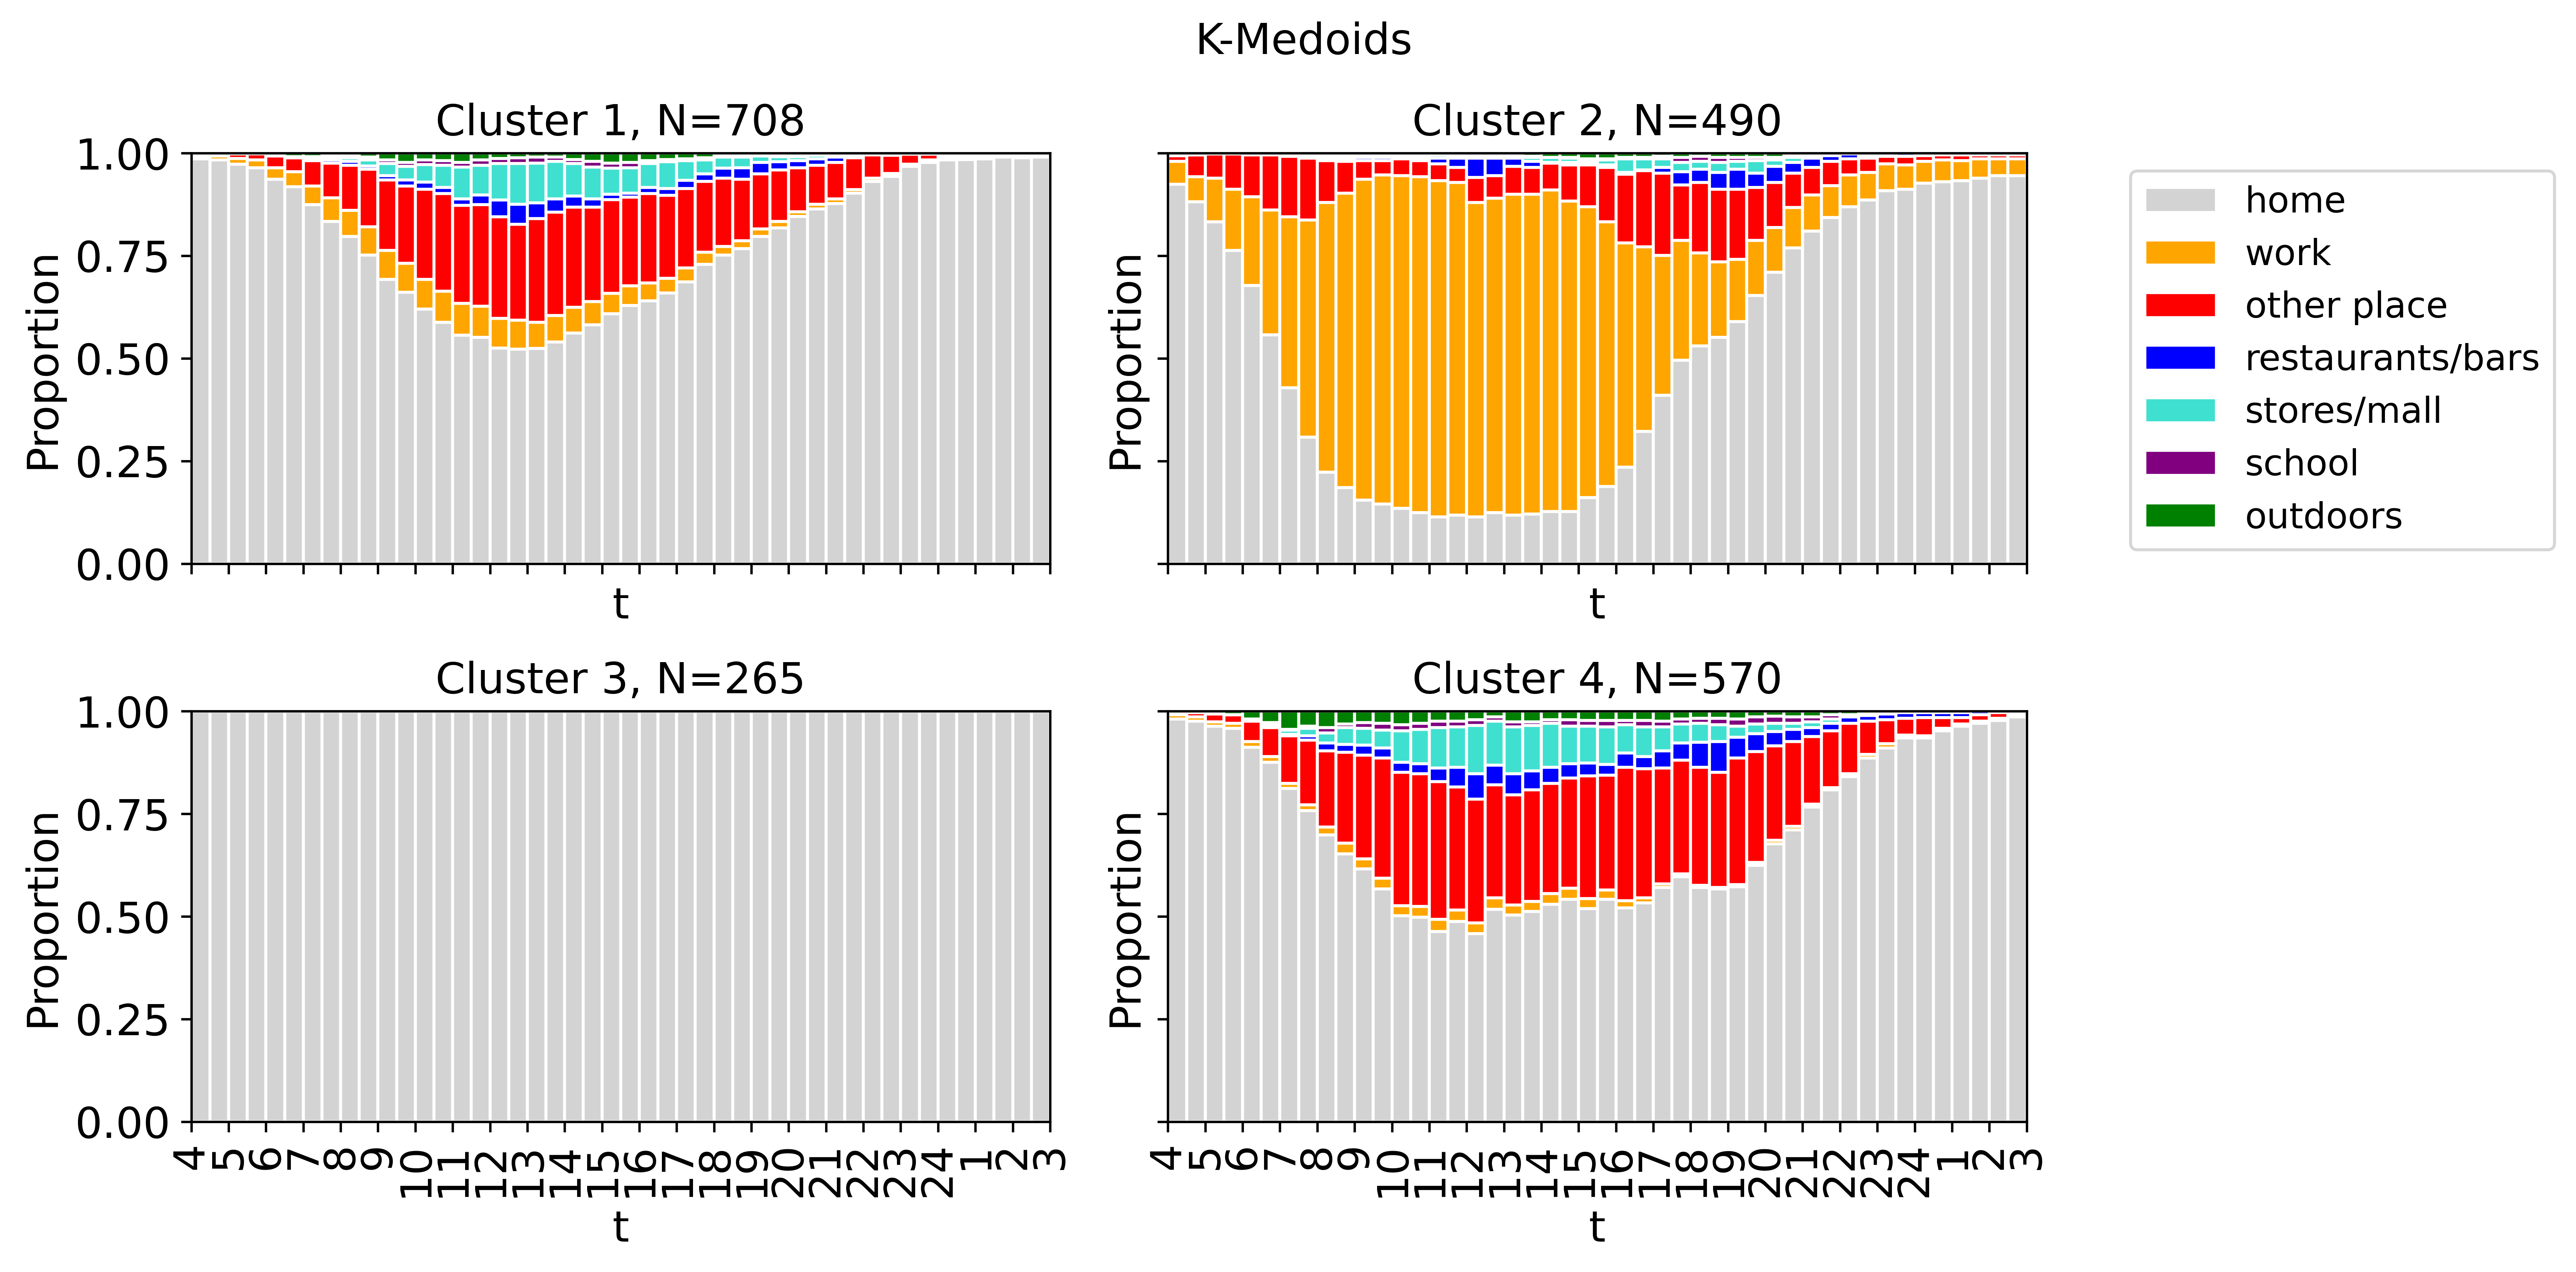

In [16]:
# Example K-Medoids clustering with 4 clusters

# D = (n x n) precomputed distance matrix (symmetric, zeros on diagonal)
# wA = (n,) nonnegative weights aligned with rows of D
# K = number of clusters

# convert hamming matrix to symmetric with 0s on diagnoals
#D = dist_matrix_hamming + dist_matrix_hamming.T
#np.fill_diagonal(D, 0.0)
K = 4
W = resp['TUFINLWGT'].values

best = fit_weighted_kmedoids_with_restarts(
    cosine_D, W, K, n_restarts=20, init="kmedoids++", max_iter=200, tol=1e-6
)
labels_k  = best["labels"]   # 0..K-1
medoids = best["medoids"]  # indices of medoid sequences
print("Cluster sizes:", np.bincount(labels_k))


# Plot cluster tempograms
legend_labels = {
    1: "home",
    2: "work",
    3: "other place",
    4: "restaurants/bars",
    5: "stores/mall",
    6: "school",
    7: "outdoors",
}
cluster_tempogram_weighted_wrapper(seq, labels_k + 1, suptitle='K-Medoids', legend_labels=legend_labels)

In [22]:
best

{'medoids': array([  42, 1437, 1862,    6]),
 'labels': array([1, 3, 0, ..., 0, 3, 0]),
 'inertia': 1522363.5351892952,
 'seed': 579362555}

In [38]:
from collections import defaultdict

dist_to_medoid = defaultdict(list)
for i,l in enumerate(best['labels']):
    dist_to_medoid[l].append(cosine_D[i, best['medoids'][l]])


dist_to_medoid_99pct = {}
for k, v in dist_to_medoid.items():
    dist_to_medoid_99pct[k] = (best['medoids'][k], np.percentile(v, 99))

dist_to_medoid_99pct

{1: (1437, 0.28682192293378117),
 3: (6, 0.07594190845573826),
 0: (42, 0.2819953947940581),
 2: (1862, 0.0)}

In [38]:
labels_k + 1

array([3, 2, 2, ..., 2, 2, 2])

## Group respondents into ACS categories

In [39]:
resp

,TUCASEID,TUYEAR,TUMONTH,TUDIARYDAY,TUDIARYDATE,GTCBSA,GTCO,TUFINLWGT,FEMALE,AGE,EMPLOYED,EMPLOY_TYPE,INCOME_GROUP,COLLEGE,MAR,CHILDREN,MAR_CHILD,RACE
0,20040707040543,2004,7,weekday,20040728,38060,4013,20255.140632,0,59.0,1,1,14.0,1,1,0,2,1
1,20040707040558,2004,7,weekend,20040731,38060,4013,8612.078956,0,44.0,1,1,14.0,1,1,0,2,1
2,20040807040006,2004,8,weekend,20040808,38060,4013,13895.869568,0,55.0,0,3,11.0,0,0,0,1,1
3,20040807040542,2004,8,weekend,20040808,38060,4013,39687.590746,0,21.0,0,3,10.0,0,0,1,1,3
4,20040807040553,2004,8,weekend,20040821,38060,4013,2537.938345,0,47.0,1,1,8.0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028,20191211192139,2019,12,weekend,20191221,38060,4013,12177.142158,0,44.0,1,1,7.0,0,0,0,1,1
2029,20191211192394,2019,12,weekday,20191211,38060,4013,69774.777569,0,21.0,1,1,13.0,0,0,0,1,4
2030,20191212190533,2019,12,weekend,20191222,38060,4013,14709.465924,1,76.0,1,2,13.0,0,1,0,2,1
2031,20191212191319,2019,12,weekend,20191228,38060,4013,28148.385455,0,25.0,1,1,11.0,0,1,0,2,1


In [17]:
### regroup respondent age and income to match what we will do with ACS

income_chars = ['less_than_35k','35k_75k','75k_100k','greater_than_100k']
age_chars = ['18 to 24', '25 to 44', '45 to 66', '67 and above']

def group_atus_income(x):
    if x<= 9:
        return 0 #income_chars[0]
    elif 10 <= x <= 13:
        return 1 #income_chars[1]
    elif x == 14:
        return 2 #income_chars[2]
    else:
        return 3 #income_chars[3]

def group_atus_age(x):
    if x <= 24:
        return 0 #age_chars[0]
    elif 25 <= x <= 44:
        return 1 #age_chars[1]
    elif 45 <= x <= 66:
        return 2 #age_chars[2]
    else:
        return 3 #age_chars[3]

In [18]:
atus_meta = resp[['TUCASEID','TUFINLWGT']].copy()

# group and code as integer
atus_meta['income'] = resp['INCOME_GROUP'].apply(lambda x: group_atus_income(x))
atus_meta['age'] = resp['AGE'].apply(lambda x: group_atus_age(x))

# make joint integer stratum code
atus_meta['joint'] = atus_meta['income'] * len(age_chars) + atus_meta['age'] 

# set cluster labels
atus_meta['cluster_label'] = labels_k

# map integer codes into string names (just for readability)
atus_meta['income_cat'] = atus_meta['income'].apply(lambda x: income_chars[x])
atus_meta['age_cat'] = atus_meta['age'].apply(lambda x: age_chars[x])

atus_meta


,TUCASEID,TUFINLWGT,income,age,joint,cluster_label,income_cat,age_cat
0,20040707040543,20255.140632,2,2,10,1,75k_100k,45 to 66
1,20040707040558,8612.078956,2,1,9,3,75k_100k,25 to 44
2,20040807040006,13895.869568,1,2,6,0,35k_75k,45 to 66
3,20040807040542,39687.590746,1,0,4,0,35k_75k,18 to 24
4,20040807040553,2537.938345,0,2,2,3,less_than_35k,45 to 66
...,...,...,...,...,...,...,...,...
2028,20191211192139,12177.142158,0,1,1,3,less_than_35k,25 to 44
2029,20191211192394,69774.777569,1,0,4,1,35k_75k,18 to 24
2030,20191212190533,14709.465924,1,3,7,0,35k_75k,67 and above
2031,20191212191319,28148.385455,1,1,5,3,35k_75k,25 to 44


In [19]:
atus_meta['joint'].min(), atus_meta['joint'].max()

(0, 15)

In [20]:
atus_meta['joint'].nunique() == len(income_chars) * len(age_chars)

True

In [21]:
atus_meta.to_csv('data/processed/atus_meta.csv', index=False)